# Lab 5 Data Processing Jupyter Notebook
Caroline & Bekah

In [50]:
# Import the Necessary Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from scipy.signal import welch # We'll need this for power spectral density estimation eventually

# Allow for interactive plotting in Jupyter notebooks, comment out the line to turn this off. 
# The % sign is a Jupyter magic command that enables the use of widgets in the notebook.
# This requires installing the ipympl package, so if you get an error on this line, 
# you may need to install it first by running: pip install ipympl

%matplotlib widget 

# For interactive data point selection in plots, this library is useful.
import mplcursors 

# Add this line of code to each plot if you want cursors: 
# mplcursors.cursor(hover=False, multiple=True)  # Enable interactive cursor for data point selection, right-click to remove cursor

# Use this command to set the default font size for your plots.
sns.set_context("notebook")
# Options from smallest to largest: "paper", "notebook", "talk", "poster"

Remember to use both Markdown and Code cells to import and plot your data. Refer back to the Tutorial if you need example code.

# Importing & Pre-Processing Heater Data

In [51]:
# import the dataset
myData = pd.read_csv("finaladjustedheater.csv")

# convert time from ms to minutes
myData['Time (min)'] = myData['Time (ms)'] / 60000

# smoothing function to improve quality for temperature, power, and current data
myData['Smoothed Temperature'] = myData[' Temperature (C)'].rolling(window=5).mean()
myData['Smoothed Current'] = myData[' Current (mA)'].rolling(window=5).mean()
myData['Smoothed Power'] = myData[' Power (mW)'].rolling(window=5).mean()

# Temperature Plot
Block over the course of the experiment

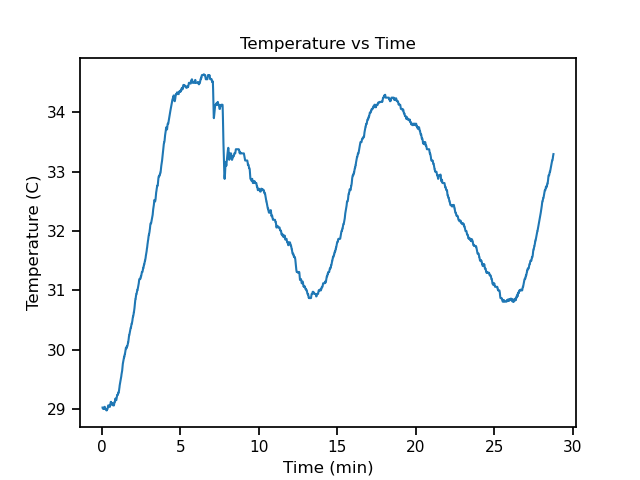

In [52]:
plt.figure()  # Create a new figure
sns.lineplot(x="Time (min)", y="Smoothed Temperature", data=myData)
plt.title("Temperature vs Time")
plt.xlabel("Time (min)")
plt.ylabel("Temperature (C)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Current Plot
Current supplied to heater throughout the experiment

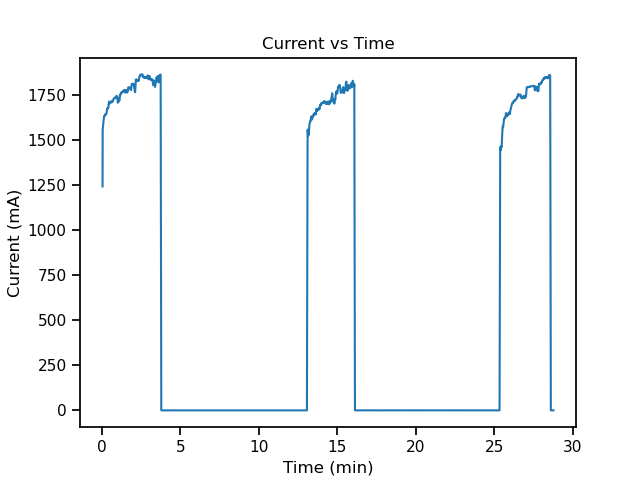

In [53]:
plt.figure()  # Create a new figure
sns.lineplot(x="Time (min)", y="Smoothed Current", data=myData)
plt.title("Current vs Time")
plt.xlabel("Time (min)")
plt.ylabel("Current (mA)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Heater Power & Energy Over Time Plot

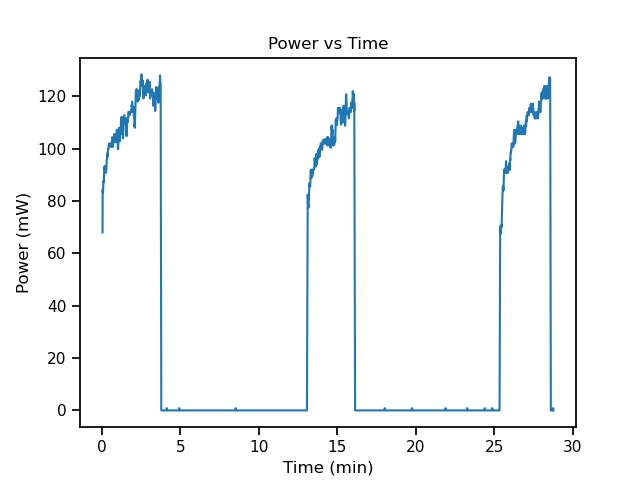

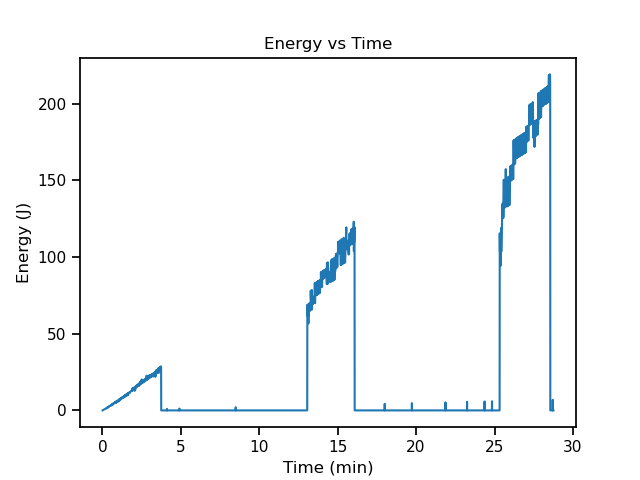

In [54]:
plt.figure()  # Create a new figure
sns.lineplot(x="Time (min)", y="Smoothed Power", data=myData)
plt.title("Power vs Time")
plt.xlabel("Time (min)")
plt.ylabel("Power (mW)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# calculate energy
myData['Energy (J)'] = (myData[' Power (mW)']/1000) * (myData['Time (ms)'] / 1000)  # Convert ms to seconds and mW to W for energy calculation

plt.figure()  # Create a new figure
sns.lineplot(x="Time (min)", y="Energy (J)", data=myData)
plt.title("Energy vs Time")
plt.xlabel("Time (min)")
plt.ylabel("Energy (J)")

mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

plt.show()

# Efficiency Calculations
1. What is the efficiency of heating the block from room temperature to the set point of 33℃? 
2. What is the efficiency of heating the block from 31℃ to 35℃ (e.g. where the system will operate most of the time, during the hysteresis loop)? 
3. What is the average rate of heat loss for the block when the heater turns off at 35℃ until it turns back on at 31℃ ? 
4. Once the block reaches 33 ℃, how much energy is required to keep the block at constant temperature for 15 minutes? 


η = (Useful Energy Delivered/Energy Input)

η = mcΔT/ ((Vheater iheater) ∗ Time)

In [ ]:
# define variables
m = 63.5 # mass of the block in grams
c = 0.9 # specific heat capacity of the block in J/g°C for aluminum shell

# 1. What is the efficiency of heating the block from room temperature to the set point of 33℃? 
t_29_33 = 33 - 29


# 2. What is the efficiency of heating the block from 31℃ to 35℃ (e.g. where the system will operate most of the time, during the hysteresis loop)? 
# 3. What is the average rate of heat loss for the block when the heater turns off at 35℃ until it turns back on at 31℃ ? 
t_35_31 = 35 - 31
Q_out = (m*c*t_35_31)
# 4. Once the block reaches 33 ℃, how much energy is required to keep the block at constant temperature for 15 minutes? 